In [4]:
import re, os, glob
import pandas as pd
import krippendorff
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score

from datasets import Dataset

from dotenv import load_dotenv
load_dotenv()

True

# Annotations - November 2024

In [5]:
data_dir = os.getenv('MAIN_ANNOTS')

BASE_COLS = ['fname', 'periodical', 'id', 'year', 'volume', 'nr', 'page', 'paragraph']
FLAG_COLS = [
    'ocr_errors', 'contents_page', 'publication_info', 'art_author', 
    'art_title', 'opinionated', 'dialogue', 'caption'
]
GENRE_COLS = [
    'Academic', 'Administrative', 'Advertisement', 'Announcement', 'Appeal', 
    'Argumentative', 'Bio', 'News', 'Fiction', 'Guidance', 'Informational', 
    'Interactive', 'Invitation', 'Legal', 'PO_report', 'QA'
]

EXCEL_COLS = ['__'] + BASE_COLS + FLAG_COLS + GENRE_COLS + ['comment']

all_files = glob.glob(os.path.join(data_dir, '**/*.xlsx'), recursive=True)

df_list = []
for f in all_files:
    try:
        
        path_parts = os.path.normpath(f).split(os.sep)
        annotator_name = os.path.basename(f).split('.')[0].split('_')[-1]
        lang, part_no = path_parts[-2].split('_')

        df = pd.read_excel(f, header=0, skiprows=[1], names=EXCEL_COLS)
        
        df.insert(0, 'annotator_name', annotator_name)
        df.insert(1, 'part_no', int(part_no))
        df.insert(2, 'language', lang)
        
        df_list.append(df)
    except (IOError, ValueError, IndexError) as e:
        print(f"Skipping file {f} due to error: {e}")

if not df_list:
    raise FileNotFoundError("No valid annotation files found. Check the 'MAIN_ANNOTS' path.")
    
data = pd.concat(df_list, ignore_index=True)

data['paragraph'] = data['paragraph'].astype(str).str.strip()

all_flag_cols = FLAG_COLS + GENRE_COLS
# Convert columns to numeric
data[all_flag_cols] = data[all_flag_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype('int8')

# Filter for rows that have at least one valid genre annotation.
data = data[data[GENRE_COLS].sum(axis=1) > 0].copy()

data['genre'] = data[GENRE_COLS].idxmax(axis=1)

other_cols = ['contents_page', 'publication_info', 'caption', 'art_author', 'art_title']
other_mask = data[other_cols].sum(axis=1) > 0
data['other'] = pd.NA
data.loc[other_mask, 'other'] = data.loc[other_mask, other_cols].idxmax(axis=1)

final_cols = [
    'annotator_name', 'part_no', 'language', 'fname', 'periodical', 'id', 'year', 'nr', 
    'page', 'paragraph', 'genre', 'other', 'ocr_errors', 'opinionated', 'dialogue'
]
final_df = data[final_cols].reset_index(drop=True)



In [9]:
print(f"\nTotal rows in final DataFrame: {len(final_df)}")
print(f"Total annotated paragraphs: {len(final_df.drop_duplicates(subset=['fname', 'periodical', 'id', 'year', 'nr', 'page', 'paragraph']))}")


Total rows in final DataFrame: 28623
Total annotated paragraphs: 23031


In [10]:
# Size of annotations per annotator
print(final_df.groupby(['language', 'part_no', 'annotator_name']).size().to_latex())

\begin{tabular}{lllr}
\toprule
 &  &  & 0 \\
language & part_no & annotator_name &  \\
\midrule
\multirow[t]{4}{*}{deu} & \multirow[t]{2}{*}{1} & AAndersen & 1304 \\
 &  & YStoykova & 4443 \\
\cline{2-4}
 & \multirow[t]{2}{*}{2} & JSchuh & 816 \\
 &  & NPopp & 3405 \\
\cline{1-4} \cline{2-4}
\multirow[t]{3}{*}{swe} & 1 & INilsson & 10362 \\
\cline{2-4}
 & \multirow[t]{2}{*}{2} & HJohansson & 3788 \\
 &  & SKreft & 4505 \\
\cline{1-4} \cline{2-4}
\bottomrule
\end{tabular}



In [11]:
final_df.query('language == "swe" and part_no == 1')['genre'].value_counts()

genre
PO_report         2256
Advertisement     1295
Informational     1151
Fiction           1053
Guidance           964
Argumentative      806
Bio                554
Academic           502
Interactive        406
Administrative     389
Announcement       201
Legal              201
Invitation         173
QA                 142
Appeal             137
News               132
Name: count, dtype: int64

Number of paragraphs of length > 100 white-space splitted tokens:       1796


count    28623.000000
mean        31.299479
std         39.523049
min          0.000000
25%          4.000000
50%         15.000000
75%         44.000000
max        420.000000
Name: length_tokens, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x75166d8f44a0>,
 'caps': [<matplotlib.lines.Line2D at 0x75166d8f6fc0>,
 'boxes': [<matplotlib.lines.Line2D at 0x75166d55ac00>],
 'medians': [<matplotlib.lines.Line2D at 0x75166d8f5eb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x75166d8f5640>],
 'means': []}

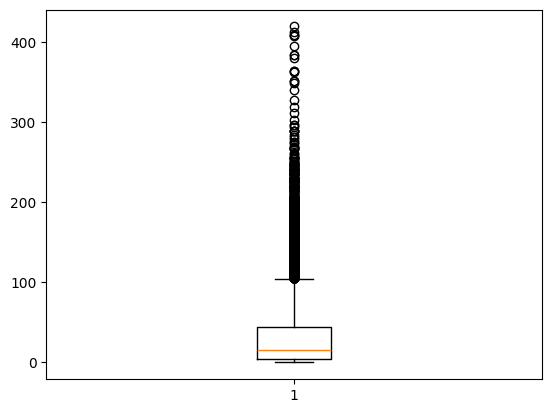

In [12]:
final_df['length_tokens'] = final_df.paragraph.apply(lambda text: len(text.split()))
print(f"Number of paragraphs of length > 100 white-space splitted tokens: \
      {final_df[final_df['length_tokens'] > 100].__len__()}")
display(final_df.length_tokens.describe())
plt.boxplot(final_df['length_tokens'].tolist())

In [13]:
def calculate__overall_agreement(df):
    
    annotations = df.values.T.tolist()  # rows as annotators
    alpha = krippendorff.alpha(reliability_data=annotations, level_of_measurement='nominal')
    # print(f"Krippendorff's alpha: {alpha}")

    return alpha

def show_and_save___heatmap(subset, language, part):

    conf_mat = pd.crosstab(subset['Annotator 1'], subset['Annotator 2'])

    # conf_mat_norm = conf_mat.div(conf_mat.sum(axis=1), axis=0)#fmt=".2f"

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap=sns.color_palette("crest", as_cmap=True),
                )
    plt.title("Inter-Annotator Agreement Confusion Matrix", fontsize=16, fontweight='bold')
    plt.xlabel("Annotator 2")
    plt.ylabel("Annotator 1")
    plt.xticks(fontsize=10, fontfamily='Lato')
    plt.yticks(fontsize=10, fontfamily='Lato')
    plt.tight_layout()
    plt.savefig(f'figures/confusion_matrix_{language}_part{part}.png', dpi=330)  
    plt.show()

def calculate_per_genre_agreement(df):
    """
    Computes per-genre Cohen's kappa, percentage agreement, and counts
    for two annotators in a given subset DataFrame (pivoted form).
    """
    results = []

    # Expect exactly two annotators' columns
    annotators = df.columns[:2]
    a1, a2 = df[annotators[0]], df[annotators[1]]

    # All genres present in the data
    all_genres = sorted(set(a1.unique()) | set(a2.unique()))

    for genre in all_genres:
        # Binary labels: 1 if genre == this, else 0 ("other")
        a1_binary = (a1 == genre).astype(int)
        a2_binary = (a2 == genre).astype(int)

        # Cohen’s κ for this genre vs all others
        kappa = cohen_kappa_score(a1_binary, a2_binary)

        # Percentage agreement
        pct_agreement = np.mean(a1_binary == a2_binary) * 100

        # Counts per annotator
        count_a1 = a1_binary.sum()
        count_a2 = a2_binary.sum()

        results.append({
            "Genre": genre,
            "Cohen κ": round(kappa, 2),
            "% Agreement": round(pct_agreement),
            f"{annotators[0]} count": int(count_a1),
            f"{annotators[1]} count": int(count_a2)
        })

    return pd.DataFrame(results)



results = []
per_genre_results=[]
for language in final_df.language.unique():
    for part in final_df.part_no.unique():
        print(f'Language: {language}, Part: {part}')

        subset = final_df.query("language == @language and part_no == @part")
        subset_filtered = subset[subset.length_tokens <= 44].copy()

        if len(subset.annotator_name.unique()) < 2:
            print(f"Not enough annotators for language {language}, part {part}. Skipping...")
            break

        subset = subset.pivot(index=['fname', 'periodical', 'id', 'year', 'nr', 'page', 'paragraph'], columns='annotator_name', values='genre')    
        subset = subset.dropna(axis=0, how='any')
        print(f"Number of paragraphs before filtering by length <= 44 tokens: {len(subset)}")

        # filter by paragraph length
        subset_filtered = subset_filtered.pivot(index=['fname', 'periodical', 'id', 'year', 'nr', 'page', 'paragraph'], columns='annotator_name', values='genre')    
        subset_filtered = subset_filtered.dropna(axis=0, how='any')
        print(f"Number of paragraphs after filtering by length <= 44 tokens: {len(subset_filtered)}")

        # Krippendorff's Alpha
        alpha = calculate__overall_agreement(subset.dropna(axis=0, how='any'))
        print(f"Krippendorff's alpha before filtering by length <= 44 tokens for Group {part} and Language {language}: {alpha}")
        alpha_filtered = calculate__overall_agreement(subset_filtered.dropna(axis=0, how='any'))
        print(f"Krippendorff's alpha after filtering by length <= 44 tokens for Group {part} and Language {language}: {alpha_filtered}")

        subset.columns = ["Annotator 1", "Annotator 2"]
        
        # Cohen's Kappa
        a1, a2 = subset["Annotator 1"], subset["Annotator 2"]
        kappa = cohen_kappa_score(a1, a2)

        # Percentage Agreement
        pct_agreement = np.mean(a1 == a2) * 100

        results.append({
            "language": language,
            "part_no": part,
            "α": round(alpha, 2),
            "κ": round(kappa, 2),
            "%": round(pct_agreement, 2)
        })

        # show_and_save___heatmap(subset, language, part)

        genre_agreement_df = calculate_per_genre_agreement(subset)
        genre_agreement_df.insert(0, "language", language)
        genre_agreement_df.insert(1, "part", part)

        per_genre_results.append(genre_agreement_df)

        print("-------*-------")


results_df = pd.DataFrame(results)

avg_row = {
    "language": "Average",
    "part_no": "",
    "α": round(results_df["α"].mean(), 2),
    "κ": round(results_df["κ"].mean(), 2),
    "%": round(results_df["%"].mean(), 1)
}

results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

print(results_df.to_string(index=False))

print(results_df.to_latex(index=False,
    caption="Inter-annotator reliability metrics per group",
    label="tab:agreement",
    column_format="llccc",
    escape=False,
    float_format="%.2f"
))
# 6% - German group 1
# 4% - German Group 2
# 1.5% - Swedish Group 1



Language: swe, Part: 2
Number of paragraphs before filtering by length <= 44 tokens: 3520
Number of paragraphs after filtering by length <= 44 tokens: 2885
Krippendorff's alpha before filtering by length <= 44 tokens for Group 2 and Language swe: 0.6650399807029318
Krippendorff's alpha after filtering by length <= 44 tokens for Group 2 and Language swe: 0.6823620636970922
-------*-------
Language: swe, Part: 1
Not enough annotators for language swe, part 1. Skipping...
Language: deu, Part: 2
Number of paragraphs before filtering by length <= 44 tokens: 778
Number of paragraphs after filtering by length <= 44 tokens: 489
Krippendorff's alpha before filtering by length <= 44 tokens for Group 2 and Language deu: 0.4560021283548822
Krippendorff's alpha after filtering by length <= 44 tokens for Group 2 and Language deu: 0.47649641567737977
-------*-------
Language: deu, Part: 1
Number of paragraphs before filtering by length <= 44 tokens: 1294
Number of paragraphs after filtering by length

In [14]:
################
#per-genre table for latex
################
per_genre_results_df = pd.concat(per_genre_results, ignore_index=True)
# print(per_genre_results_df.to_string(index=False))
final_table = per_genre_results_df.set_index(['Genre', 'language', 'part']).sort_index()
final_table.rename(columns={
    'Cohen κ': "Cohen's $\\kappa$",
    '% Agreement': '\\% Agreement',
    'Annotator 1 count': 'Annotator 1 Count',
    'Annotator 2 count': 'Annotator 2 Count'
}, inplace=True)
latex_code = final_table.to_latex(
    multirow=True,      
    caption='Inter-Annotator Agreement Metrics by Genre, Language, and Part.',
    label='tab:agreement_metrics',
    column_format='llrrrr' # l=left, r=right alignment for columns
)
print(latex_code)


\begin{table}
\caption{Inter-Annotator Agreement Metrics by Genre, Language, and Part.}
\label{tab:agreement_metrics}
\begin{tabular}{llrrrr}
\toprule
 &  &  & Cohen's $\kappa$ & \% Agreement & Annotator 1 Count & Annotator 2 Count \\
Genre & language & part &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{Academic} & \multirow[t]{2}{*}{deu} & 1 & 0.270000 & 97 & 16 & 41 \\
 &  & 2 & 0.320000 & 88 & 33 & 115 \\
\cline{2-7}
 & swe & 2 & 0.750000 & 97 & 211 & 188 \\
\cline{1-7} \cline{2-7}
\multirow[t]{3}{*}{Administrative} & \multirow[t]{2}{*}{deu} & 1 & 0.270000 & 99 & 3 & 19 \\
 &  & 2 & 0.000000 & 99 & 6 & 0 \\
\cline{2-7}
 & swe & 2 & 0.360000 & 98 & 21 & 94 \\
\cline{1-7} \cline{2-7}
\multirow[t]{3}{*}{Advertisement} & \multirow[t]{2}{*}{deu} & 1 & 0.880000 & 96 & 303 & 313 \\
 &  & 2 & 0.870000 & 96 & 130 & 137 \\
\cline{2-7}
 & swe & 2 & 0.770000 & 94 & 685 & 485 \\
\cline{1-7} \cline{2-7}
\multirow[t]{3}{*}{Announcement} & \multirow[t]{2}{*}{deu} & 1 & 0.380000 & 95 & 63 & 49 \\
 &  &

## Distribution of Genres in Annotator 1

In [ ]:
final_df.query('language == "swe" and part_no == 1 and periodical == "xml_Status"')['genre'].value_counts()

genre
Interactive      373
Fiction          316
Advertisement    131
Argumentative     88
Informational     31
PO_report         11
News               9
Bio                8
Legal              7
Announcement       5
Academic           3
Invitation         2
Appeal             1
Guidance           1
Name: count, dtype: int64

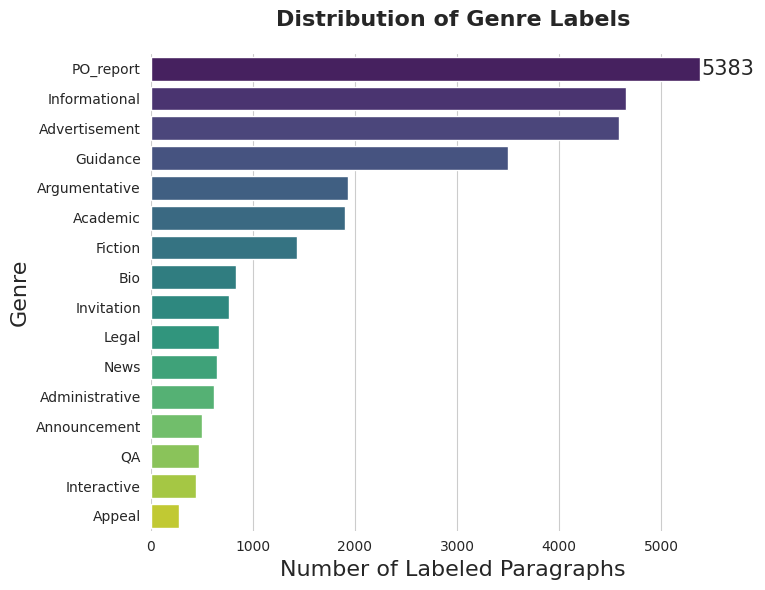

In [29]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

# .query('language == "swe" and part_no == 1')
plot_data = final_df['genre'].value_counts().reset_index(name='Number of Labeled Paragraphs')
ax = sns.barplot(
    data=plot_data,
    x="Number of Labeled Paragraphs",
    y="genre",
    palette="viridis",
    hue="genre",
    orient='h'
)
title = 'Distribution of Genre Labels (Swedish, Part 1)'
title = 'Distribution of Genre Labels'
plt.title(title, fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Labeled Paragraphs', fontsize=16)
plt.ylabel('Genre', fontsize=16)

ax.bar_label(ax.containers[0], padding=1, fontsize=15)


sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.xlim(0, plot_data['Number of Labeled Paragraphs'].max() * 1.1)

plt.savefig('figures/genre_distribution.png', dpi=330)

plt.show()

## Number of labeled paragraphs by language, periodical and annotator

In [ ]:
print(final_df.groupby(['language', 'periodical'])['annotator_name'].value_counts().to_latex())

\begin{tabular}{lllr}
\toprule
 &  &  & count \\
language & periodical & annotator_name &  \\
\midrule
\multirow[t]{6}{*}{deu} & \multirow[t]{4}{*}{xml_der_allergiker} & NPopp & 3405 \\
 &  & JSchuh & 816 \\
 &  & YStoykova & 382 \\
 &  & AAndersen & 353 \\
\cline{2-4}
 & \multirow[t]{2}{*}{xml_diabetiker_journal} & YStoykova & 4061 \\
 &  & AAndersen & 951 \\
\cline{1-4} \cline{2-4}
\multirow[t]{4}{*}{swe} & \multirow[t]{3}{*}{xml_Diabetes} & INilsson & 9376 \\
 &  & SKreft & 4505 \\
 &  & HJohansson & 3788 \\
\cline{2-4}
 & xml_Status & INilsson & 986 \\
\cline{1-4} \cline{2-4}
\bottomrule
\end{tabular}



## Number of labeled paragraphs in single and double-annotated

In [27]:

paragraph_key_cols = [
    'fname', 'language', 'periodical', 'id', 'year', 'nr', 'page', 'paragraph'
]

annotator_counts_per_para = final_df.groupby(
    paragraph_key_cols
)['annotator_name'].nunique()

print(
    annotator_counts_per_para.reset_index(name='n_annotators').groupby(['language', 'periodical','n_annotators'])['paragraph'].size().reset_index(name='size').to_latex()
)

\begin{tabular}{lllrr}
\toprule
 & language & periodical & n_annotators & size \\
\midrule
0 & deu & xml_der_allergiker & 1 & 2702 \\
1 & deu & xml_der_allergiker & 2 & 1127 \\
2 & deu & xml_diabetiker_journal & 1 & 3122 \\
3 & deu & xml_diabetiker_journal & 2 & 945 \\
4 & swe & xml_Diabetes & 1 & 10629 \\
5 & swe & xml_Diabetes & 2 & 3520 \\
6 & swe & xml_Status & 1 & 986 \\
\bottomrule
\end{tabular}



In [ ]:

final_distribution = annotator_counts_per_para.value_counts().sort_index()
print("\n--- Annotation Distribution ---")
print(final_distribution)
print("---------------------------------")


In [30]:

single_annotated = final_distribution.get(1, 0)
double_annotated = final_distribution.get(2, 0)
total_unique_paras = len(annotator_counts_per_para)

print(f"Total Unique Paragraphs Analyzed: {total_unique_paras}")
print(f"Single-annotated paragraphs (1 annotator): {single_annotated}")
print(f"Double-annotated paragraphs (2 annotators): {double_annotated}")

other_counts = final_distribution[final_distribution.index > 2].sum()
if other_counts > 0:
    print(f"Paragraphs with >2 annotators: {other_counts}")



Total Unique Paragraphs Analyzed: 23031
Single-annotated paragraphs (1 annotator): 17439
Double-annotated paragraphs (2 annotators): 5592


## ===

## Reannotations

In [6]:
reannotation_folder = os.getenv("REANNOTS")

dfs=[]
for file in os.listdir(reannotation_folder):
    if file.endswith("Vera.xlsx"):
        df = pd.read_excel(os.path.join(reannotation_folder,file), sheet_name="Hoja 1 - genre_labels_level-3_s",index_col=0)
        df['annotator']=["Vera"]*len(df)
        dfs+=[df]
        
    elif file.endswith("Majken.xlsx"):
        df = pd.read_excel(os.path.join(reannotation_folder,file), index_col=0)
        df['annotator']=["Majken"]*len(df)
        dfs+=[df]
        
reannotation_df = pd.concat(dfs,axis=0, ignore_index=True).pivot(index=['index','fname', 'year', 'nr', 'page', 'periodical', 'part_no', 'paragraph', ],columns='annotator',values='GENRE').reset_index()
reannotation_df.insert(2, 'language', "swe")

/zpool/aurora-main/scratch/vera/qwen3/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [15]:
subset = reannotation_df.copy(deep=True)

rename_map = dict(zip(subset.columns[-2:], ["Annotator 8", "Annotator 9"]))
subset = subset.rename(columns=rename_map).dropna(axis=0, how='any')
alpha = calculate__overall_agreement(subset.iloc[:,-2:].dropna(axis=0, how='any'))

# Cohen's Kappa
a1, a2 = subset["Annotator 8"], subset["Annotator 9"]
kappa = cohen_kappa_score(a1, a2)

# Percentage Agreement
pct_agreement = np.mean(a1 == a2) * 100

print(f"Krippendorff's alpha: {alpha}")
print(f"Cohen's kappa: {kappa}")
print(f"Percentage Agreement: {pct_agreement}")

Krippendorff's alpha: 0.8238246783245892
Cohen's kappa: 0.8239491315958397
Percentage Agreement: 86.3593603010348


In [30]:
len(subset.query("part_no == 1"))

996

In [31]:
subset.query("part_no == 1").groupby("periodical").size()

periodical
xml_Diabetes    214
xml_Status      782
dtype: int64

In [16]:
fnames_to_select = set(subset['fname'])
selected_data = final_df[final_df['fname'].isin(fnames_to_select)]
selected_data = selected_data.pivot(index=['fname', 'language', 'part_no', 'periodical', 'year', 'nr', 'page', 'paragraph'], columns='annotator_name', values='genre')
selected_data.columns = ["Annotator 7", "Annotator 1", "Annotator 6"]
selected_data.reset_index(inplace=True)
merged = subset.merge(selected_data, on=['fname', 'language', 'part_no', 'periodical', 'year', 'nr', 'page', 'paragraph'])

In [35]:
def measure_agreement_between_groups(subset):

    alpha = calculate__overall_agreement(subset.dropna(axis=0, how='any'))
    pct_agreement = np.mean(subset.nunique(axis=1).eq(1)) * 100

    print(f"Krippendorff's alpha: {alpha}")
    print(f"Percentage Agreement: {pct_agreement}")

In [36]:
subset=merged.query("part_no == 1").drop(["Annotator 7", "Annotator 6"], axis=1)

In [37]:
# Agreement across 3 annotators in Swedish Group 1
subset=merged.query("part_no == 1").drop(["Annotator 7", "Annotator 6"], axis=1)\
.filter(like="Annotator", axis=1)
measure_agreement_between_groups(subset)

Krippendorff's alpha: 0.8177040780151922
Percentage Agreement: 81.52610441767068


In [50]:
final_df.columns

Index(['annotator_name', 'part_no', 'language', 'fname', 'periodical', 'id',
       'year', 'nr', 'page', 'paragraph', 'genre', 'other', 'ocr_errors',
       'opinionated', 'dialogue', 'length_tokens'],
      dtype='object')

In [17]:
id_columns = [
    'fname', 'language', 'year', 'nr', 'page', 
    'periodical', 'part_no', 'paragraph'
]
rename_map = {
    'Annotator 8': 'Vera',
    'Annotator 9': 'Majken'
}
df_renamed = subset.rename(columns=rename_map)

df_long = df_renamed.melt(
    id_vars=id_columns,
    value_vars=['Vera', 'Majken'],   
    var_name="annotator_name",   
    value_name="genre")

In [18]:
merge_keys = [
    'fname', 'annotator_name', 'language', 'part_no', 
    'periodical', 'year', 'nr', 'page', 'paragraph', 'genre'
]

merged_df = final_df.merge(df_long, on=merge_keys, how='outer',
    # indicator=True
    )

In [76]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30749 entries, 0 to 30748
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   annotator_name  30749 non-null  object 
 1   part_no         30749 non-null  int64  
 2   language        30749 non-null  object 
 3   fname           30749 non-null  object 
 4   periodical      30749 non-null  object 
 5   id              28623 non-null  float64
 6   year            30749 non-null  int64  
 7   nr              30749 non-null  object 
 8   page            30749 non-null  int64  
 9   paragraph       30749 non-null  object 
 10  genre           30749 non-null  object 
 11  other           2197 non-null   object 
 12  ocr_errors      28623 non-null  float64
 13  opinionated     28623 non-null  float64
 14  dialogue        28623 non-null  float64
 15  length_tokens   28623 non-null  float64
dtypes: float64(5), int64(3), object(8)
memory usage: 3.8+ MB


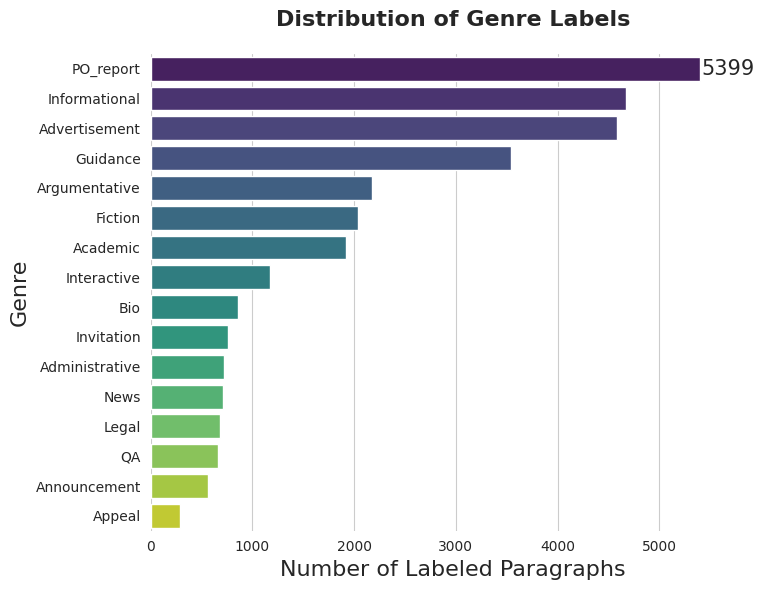

In [77]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

# .query('language == "swe" and part_no == 1')
plot_data = merged_df['genre'].value_counts().reset_index(name='Number of Labeled Paragraphs')
ax = sns.barplot(
    data=plot_data,
    x="Number of Labeled Paragraphs",
    y="genre",
    palette="viridis",
    hue="genre",
    orient='h'
)
# title = 'Distribution of Genre Labels (Swedish, Part 1)'
title = 'Distribution of Genre Labels'
plt.title(title, fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Labeled Paragraphs', fontsize=16)
plt.ylabel('Genre', fontsize=16)

ax.bar_label(ax.containers[0], padding=1, fontsize=15)


sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.xlim(0, plot_data['Number of Labeled Paragraphs'].max() * 1.1)

plt.savefig('figures/genre_distribution.png', dpi=330)

plt.show()

## Embed Dataset Paragraphs with "Qwen/Qwen3-Embedding-4B"

In [ ]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

import torch
from sentence_transformers import SentenceTransformer

embedding_model = "Qwen/Qwen3-Embedding-4B"

model = SentenceTransformer(
    embedding_model,
    device=None,  
    model_kwargs={
        'torch_dtype': torch.float16,
    },
    trust_remote_code=True                      # Required for Qwen
)

print(f"Model loaded. Using {torch.cuda.device_count()} GPUs.")

texts_to_encode = final_df["paragraph"].tolist()

embeddings = model.encode(
    texts_to_encode,
    batch_size=8,  
    show_progress_bar=True
)
final_df['embedding'] = [embedding for embedding in embeddings]
print(f"Successfully encoded {len(final_df)} rows.")
final_df.to_parquet("genre_annotations_with_embeddings.parquet", index=False)

## Analysis of Feature Correlation with Agreement/Disagreement

In [1]:
import pandas as pd
import numpy as np
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

import spacy
import textstat
from collections import Counter

from bertopic import BERTopic
from umap import umap_ as UMAP
from hdbscan import HDBSCAN

import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import normalize
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler, normalize
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity

from bertopic.representation import MaximalMarginalRelevance
# https://github.com/tsproisl/textcomplexity


/zpool/aurora-main/scratch/vera/qwen3/lib/python3.12/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [2]:
final_df = pd.read_parquet("genre_annotations_with_embeddings.parquet")

## Select Subset

In [323]:
language = 'deu'
part_no = 1

In [324]:
df = final_df.query("language == @language and part_no == @part_no")\
.pivot(index=['fname', 'periodical', 'id', 'year', 'nr', 'page', 'paragraph'], columns='annotator_name', values='genre')
df=df.dropna(axis=0, how='any')

In [ ]:
# # Group 1 Swedish
# df = df.merge(subset, on=['fname', 'periodical', 'year', 'nr', 'page', 'paragraph'])
# df = df.drop('Annotator 8', axis = 1).rename({'Annotator 9' : 'Annotator 2'}, axis=1)


In [325]:
df.columns = ["Annotator 1", "Annotator 2"]

In [326]:
df = df.reset_index()
df = df.merge(final_df[['paragraph', 'embedding']].set_index('paragraph'), on='paragraph', how='left').drop_duplicates(subset=['paragraph', 'Annotator 1','Annotator 2']) 

## Semantic Similarity

In [327]:
########
# comparison of all paragraphs in A1-G1 vs A2-G1, A2-G2, etc.
########

df_data = []

for source_genre in df['Annotator 1'].unique():
    for target_genre in df['Annotator 2'].unique():
        
        source_embeddings = df[df['Annotator 1'] == source_genre]
        target_embeddings = df[df['Annotator 2'] == target_genre]

        # select the number of paragraph pairs to sort by similarity and average 
        k = np.min([source_embeddings.shape[0], target_embeddings.shape[0]])

        source_embeddings = normalize(np.vstack(source_embeddings['embedding'].values))
        target_embeddings = normalize(np.vstack(target_embeddings['embedding'].values))

        pairwise = np.dot(source_embeddings, target_embeddings.T).flatten()
        # include only n similar paragraphs
        # similarity = np.mean(np.sort(pairwise)[-k:])
        similarity = np.mean(pairwise)
        
        df_data.append({
            'Annotator 1': source_genre,
            'Annotator 2': target_genre,
            'semantic_similarity': similarity
        })

semantic_similarity = pd.DataFrame(df_data)
semantic_similarity_cm = semantic_similarity.pivot(index='Annotator 1', columns='Annotator 2', values='semantic_similarity')

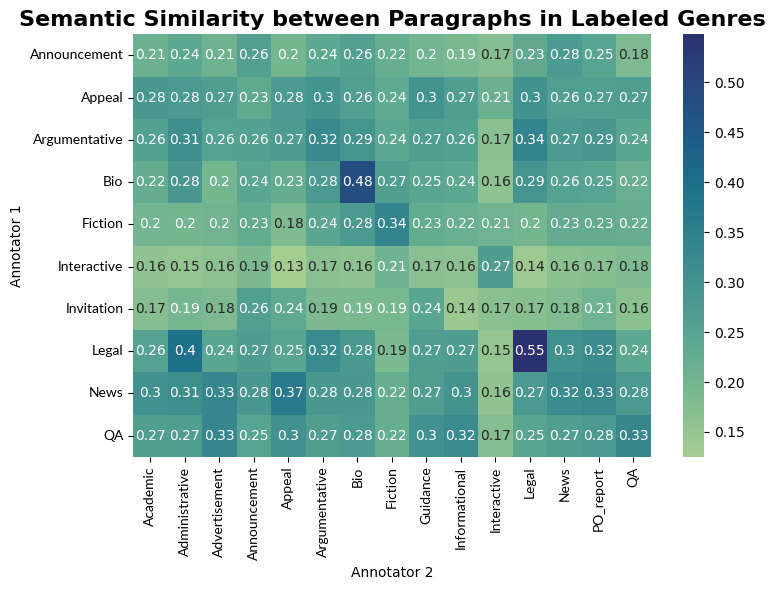

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(semantic_similarity_cm, annot=True, fmt=".2", cmap=sns.color_palette("crest", as_cmap=True),
            )
plt.title("Semantic Similarity between Paragraphs in Labeled Genres", fontsize=16, fontweight='bold')
plt.xlabel("Annotator 2")
plt.ylabel("Annotator 1")
plt.xticks(fontsize=10, fontfamily='Lato')
plt.yticks(fontsize=10, fontfamily='Lato')
plt.tight_layout()
plt.savefig(f'figures/HeatmapSemanticSimilarity_{language}_{part_no}.png', dpi=330)  
plt.show()


## Structural Features Calculation

In [328]:
nlp = None
if language == "deu":
    try:
        nlp = spacy.load("de_core_news_md")
    except IOError:
        print("Model not found. Run: python -m spacy download de_core_news_md")
    textstat.set_lang('de')
    readability_metric = 'readability_wiener'
    print("Loaded German (deu) model.")
    
elif language == "swe":
    try:
        nlp = spacy.load("sv_core_news_md")
    except IOError:
        print("Model not found. Run: python -m spacy download sv_core_news_md")
    textstat.set_lang('sv_SE') 
    readability_metric = 'readability_lix'
    print("Loaded Swedish (swe) model.")
    
else:
    print(f"Language '{language}' not supported.")
    

def get_linguistic_features(text, nlp_model, lang_code):

    if not isinstance(text, str) or not text.strip():
        return {}
    
    doc = nlp_model(text)
    
    all_tokens = [token.text.lower() for token in doc if token.is_alpha]
    sentences = list(doc.sents)
    pos_tags = [token.pos_ for token in doc]
    pos_counts = Counter(pos_tags)
    total_pos = sum(pos_counts.values())

    unique_tokens = set(all_tokens)
    ttr = len(unique_tokens) / len(all_tokens) if all_tokens else 0
    avg_word_len = np.mean([len(t) for t in all_tokens]) if all_tokens else 0
    avg_sent_len = np.mean([len(sent) for sent in sentences]) if sentences else 0
    
    content_tags = {'NOUN', 'VERB', 'ADJ', 'ADV'}
    lexical_density = sum(1 for p in pos_tags if p in content_tags) / len(all_tokens) if all_tokens else 0
    
    # Readability
    readability_metric_name = 'readability_score'
    readability_score = np.nan
    
    try:
        if lang_code == "deu":
            readability_score = textstat.wiener_sachtextformel(text, 1)
            readability_metric_name = 'readability_wiener'
        elif lang_code == "swe":
            readability_score = textstat.lix(text)
            readability_metric_name = 'readability_lix'
    except Exception:
        # textstat fails on very short/empty texts
        pass 

    # Syntactic Dependencies
    dep_dists = []
    for token in doc:
        if token.dep_ != "ROOT":
            distance = abs(token.i - token.head.i)
            dep_dists.append(distance)
    avg_dep_dist = np.mean(dep_dists) if dep_dists else 0

    def get_sentence_height(sent_root):
        """Recursively calculates max depth from a token."""
        return 1 + max((get_sentence_height(child) for child in sent_root.children), default=0)

    heights = []
    for sent in doc.sents:
        if sent.root:
            heights.append(get_sentence_height(sent.root))
    avg_tree_height = np.mean(heights) if heights else 0

    # Return feature dictionary
    feature_dict = {
        'unique_tokens': unique_tokens,
        'avg_sent_len': avg_sent_len,  
        'avg_word_len': avg_word_len,  
        'ttr': ttr,
        'lexical_density': lexical_density,
        readability_metric_name: readability_score,
        'avg_tree_height': avg_tree_height,
        'avg_dep_dist': avg_dep_dist,
        'noun_ratio': pos_counts.get('NOUN', 0) / total_pos if total_pos else 0,
        'verb_ratio': pos_counts.get('VERB', 0) / total_pos if total_pos else 0,
        'adj_ratio': pos_counts.get('ADJ', 0) / total_pos if total_pos else 0,
        'adv_ratio': pos_counts.get('ADV', 0) / total_pos if total_pos else 0,
        'adp_ratio': pos_counts.get('ADP', 0) / total_pos if total_pos else 0,
        'pron_ratio': pos_counts.get('PRON', 0) / total_pos if total_pos else 0,
        'sconj_ratio': pos_counts.get('SCONJ', 0) / total_pos if total_pos else 0,
        'cconj_ratio': pos_counts.get('CCONJ', 0) / total_pos if total_pos else 0,
        'part_ratio': pos_counts.get('PART', 0) / total_pos if total_pos else 0,
        'punct_ratio': pos_counts.get('PUNCT', 0) / total_pos if total_pos else 0,
        'num_ratio': pos_counts.get('NUM', 0) / total_pos if total_pos else 0,
        'aux_ratio': pos_counts.get('AUX', 0) / total_pos if total_pos else 0,
        'propn_ratio': pos_counts.get('PROPN', 0) / total_pos if total_pos else 0
    }
    return feature_dict

if nlp:
    
    features_series = df['paragraph'].apply(lambda text: get_linguistic_features(text, nlp, language))
    features_df = pd.DataFrame(features_series.tolist(), index=df.index)
    df = pd.concat([df, features_df], axis=1)
    
    print("Linguistic features successfully calculated and added to DataFrame.")
    print(df.head())
else:
    print("Analysis was not run as the NLP model was not loaded.")
features_names=list(features_series.tolist()[0].keys())[1:]

Loaded German (deu) model.
Linguistic features successfully calculated and added to DataFrame.
                                       fname          periodical    id  year  \
0  Der_Allergiker_1959_vol000_nr001_0000.xml  xml_der_allergiker  1834  1959   
2  Der_Allergiker_1959_vol000_nr001_0000.xml  xml_der_allergiker  1834  1959   
4  Der_Allergiker_1959_vol000_nr001_0000.xml  xml_der_allergiker  1834  1959   
6  Der_Allergiker_1959_vol000_nr001_0000.xml  xml_der_allergiker  1834  1959   
8  Der_Allergiker_1959_vol000_nr001_0001.xml  xml_der_allergiker  1820  1959   

      nr  page                                          paragraph  \
0  nr001     0  Die Bezeichnung „Heufieber" oder „Heuschnupfen...   
2  nr001     0  Die Jahresberichte stellten an den Vorstand un...   
4  nr001     0  Seit Bestehen unseres Bundes haben wir den Mit...   
6  nr001     0  Waren Blütezeit und Beschwerden vorüber, so be...   
8  nr001     1                       ASTHMA - ALLERGIE - ATEMWEGE   

      Ann

## Structural Similarity

### v 1. create structural vector per genre --> avg each feature

In [ ]:
# create structural vector per genre --> avg each feature
def get_feature_vector(annotator_column, df):

    avg_vectors = df.groupby(
        [annotator_column]
    )[features_names].mean()
    
    avg_vectors = avg_vectors.fillna(0)
    avg_vectors = avg_vectors.T.drop_duplicates().T
    
    return avg_vectors

vec_A1 = get_feature_vector('Annotator 1', df)
vec_A2 = get_feature_vector('Annotator 2', df)

scaler = MinMaxScaler()
scaler.fit(vec_A1) 
scaled_A1 = scaler.transform(vec_A1)
scaled_A2 = scaler.transform(vec_A2)

pairwise_similarity = cosine_similarity(scaled_A1, scaled_A2)

structural_similarity_cm = pd.DataFrame(
    pairwise_similarity, 
    index=vec_A1.index, 
    columns=vec_A2.index
)

### v2. create structural matrix per genre to further use top-k mean

In [329]:
def stack_norm(data, feature_type='embedding', readability_metric_name=None):
    """
    Normalize embeddings or linguistic feature sets.

    Parameters
    ----------
    data : pd.Series or pd.DataFrame
        - If 'embedding': Series of numpy arrays.
        - If 'linguistic_features': DataFrame or Series of dicts containing features.
    feature_type : str, default='embedding'
        'embedding' or 'linguistic_features'
    readability_metric_name : str, optional
        Name of readability metric (only for linguistic features).

    Returns
    -------
    np.ndarray
        2D normalized array (n_samples, n_features)
    """

    # --- Embeddings case ---
    if feature_type == 'embedding':
        if isinstance(data, pd.DataFrame):
            # in case user passes df[['embedding']]
            ser = data.squeeze()
        else:
            ser = data

        arr = np.vstack(ser.values).astype(np.float32)
        return normalize(arr, axis=1)

    # --- Linguistic features case ---
    elif feature_type == 'linguistic_features':
        # Convert Series of dicts → DataFrame if needed
        if isinstance(data, pd.Series):
            if isinstance(data.iloc[0], dict):
                df = pd.DataFrame(data.tolist())
            else:
                df = pd.DataFrame(data)
        elif isinstance(data, pd.DataFrame):
            df = data.copy()
        else:
            raise TypeError("For linguistic features, input must be a Series or DataFrame.")

        # --- Feature groups ---
        magnitude_feats = ['avg_sent_len', 'avg_word_len',
                           'avg_tree_height', 'avg_dep_dist']
        ratio_feats = [f for f in df.columns if f.endswith('_ratio')] + ['ttr', 'lexical_density']
        read_feats = [readability_metric_name] if readability_metric_name in df.columns else []

        # --- Step 1: Log-transform magnitude features ---
        for col in magnitude_feats:
            if col in df.columns:
                df[col] = np.log1p(df[col])

        # --- Step 2: Scale each feature group with MinMaxScaler ---
        scaler = MinMaxScaler()
        for feats in [magnitude_feats, ratio_feats, read_feats]:
            feats = [f for f in feats if f in df.columns]
            if feats:
                df[feats] = scaler.fit_transform(df[feats])

        # --- Step 3: L2 normalize row-wise ---
        arr = df.to_numpy().astype(np.float32)
        arr = normalize(arr, axis=1)

        return arr

    else:
        raise ValueError("feature_type must be either 'embedding' or 'linguistic_features'")
    

def k_mean_similarity(A, B, k='all'):
    """
    Compute the mean of the top-k pairwise cosine similarities between two sets of normalized embeddings.

    Parameters
    ----------
    A : np.ndarray, shape (n1, d)
        First set of embeddings (rows should be L2-normalized).
    B : np.ndarray, shape (n2, d)
        Second set of embeddings (rows should be L2-normalized).
    k : int or 'all', default='all'
        Number of highest similarities to average.
        If 'all' or None, uses all pairwise similarities.

    Returns
    -------
    float
        Mean of the top-k (or all) cosine similarities.
    """
    # Compute pairwise cosine similarity (since A, B are normalized)
    sim_mat = np.dot(A, B.T)
    flat = sim_mat.ravel()

    if k == 'all' or k is None or k >= flat.size:
        return np.mean(flat)
    else:
        # Partial sort to get top-k largest values
        topk_vals = np.partition(flat, -k)[-k:]
        return np.mean(topk_vals)



In [330]:
genres1 = sorted(df['Annotator 1'].unique())
genres2 = sorted(df['Annotator 2'].unique())
# embeddings per label
emb_by_a1 = {g: stack_norm(df[df['Annotator 1'] == g][features_names], feature_type='linguistic_features', readability_metric_name=readability_metric) for g in genres1}
emb_by_a2 = {g: stack_norm(df[df['Annotator 2'] == g][features_names], feature_type='linguistic_features', readability_metric_name=readability_metric) for g in genres2}

rows = []
for g1 in genres1:
    for g2 in genres2:
        A = emb_by_a1[g1]
        B = emb_by_a2[g2]
        # k = min(A.shape[0], B.shape[0])
        k="all"
        similarity = k_mean_similarity(A, B, k=k)
        rows.append({'Annotator 1': g1, 'Annotator 2': g2, 'structural_similarity': similarity,
                     'nA': A.shape[0], 'nB': B.shape[0]})
structural_similarity = pd.DataFrame(rows)
structural_similarity_cm = structural_similarity.pivot(index = "Annotator 1", columns = "Annotator 2", values = "structural_similarity")

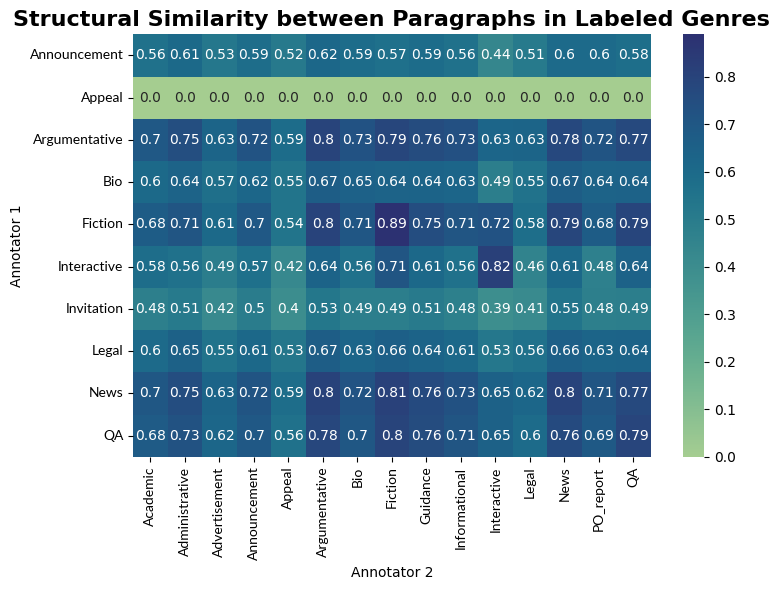

In [233]:
plt.figure(figsize=(8, 6))
sns.heatmap(structural_similarity_cm, annot=True, fmt=".2", cmap=sns.color_palette("crest", as_cmap=True),
            )
plt.title("Structural Similarity between Paragraphs in Labeled Genres", fontsize=16, fontweight='bold')
plt.xlabel("Annotator 2")
plt.ylabel("Annotator 1")
plt.xticks(fontsize=10, fontfamily='Lato')
plt.yticks(fontsize=10, fontfamily='Lato')
plt.tight_layout()
plt.savefig(f'figures/HeatmapStructuralSimilarity_{language}_{part_no}.png', dpi=330)  
plt.show()


## Word Overlap

In [121]:
df = df.loc[:, ~df.columns.duplicated()]

In [ ]:
word_overlap = np.zeros((len(df['Annotator 1'].unique()), len(df['Annotator 2'].unique())))
for i, source_genre in enumerate(sorted(df['Annotator 1'].unique())):
    for j, target_genre in enumerate(sorted(df['Annotator 2'].unique())):

        source_df = df[df['Annotator 1'] == source_genre]
        target_df = df[df['Annotator 2'] == target_genre]

        unique_source=set().union(*source_df['unique_tokens'])
        unique_target=set().union(*target_df['unique_tokens'])

        overlap = len(unique_source.intersection(unique_target))
        total_unique = len(unique_source.union(unique_target))
        word_overlap[i,j] = round(overlap/total_unique*100)

word_overlap_cm = pd.DataFrame(word_overlap, index = sorted(df['Annotator 1'].unique()), columns = sorted(df['Annotator 2'].unique()))
word_overlap_cm = word_overlap_cm.astype('int')



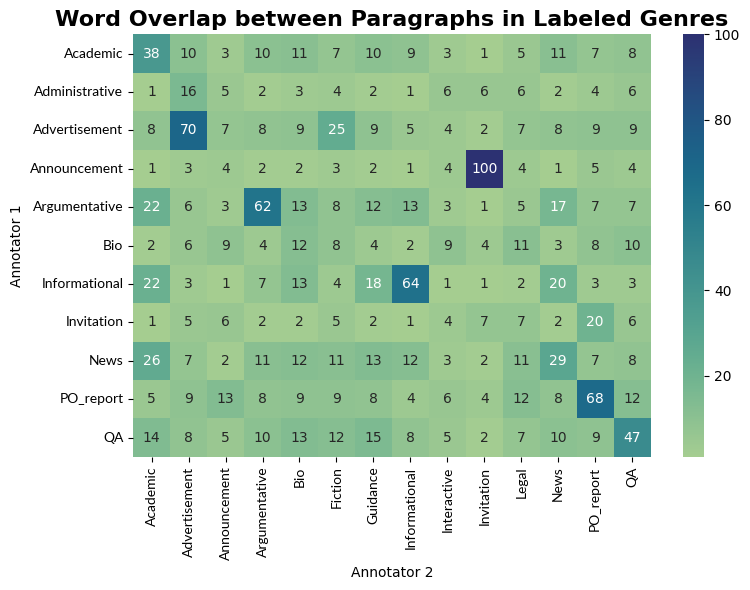

In [155]:
plt.figure(figsize=(8, 6))
sns.heatmap(word_overlap_cm, annot=True, fmt = "d", cmap=sns.color_palette("crest", as_cmap=True),
            )
plt.title("Word Overlap between Paragraphs in Labeled Genres", fontsize=16, fontweight='bold')
plt.xlabel("Annotator 2")
plt.ylabel("Annotator 1")
plt.xticks(fontsize=10, fontfamily='Lato')
plt.yticks(fontsize=10, fontfamily='Lato')
plt.tight_layout()
plt.savefig(f'figures/WordOverlap_{language}_{part_no}.png', dpi=330)  
plt.show()

## Which features signal disagreement?

In [68]:
ann1_col = 'Annotator 1'
ann2_col = 'Annotator 2'

# Sort the pair to count both "A vs B" and "B vs A"
def normalize_pair(row):
    labels = [str(row[ann1_col]), str(row[ann2_col])]
    return tuple(sorted(labels))
df['comparison_pair'] = df.apply(normalize_pair, axis=1)

# Find all rows where there was agreement (and no NaN)
agreement_mask = (
    (df[ann1_col] == df[ann2_col]) &
    (df[ann1_col].notna()) &
    (df[ann2_col].notna())
)
agreement_pair_stats_all = df[agreement_mask][features_names].mean()
agreement_pair_stats = df[agreement_mask].groupby('comparison_pair')[features_names].mean()
disagreement_pair_stats = df[~agreement_mask].groupby('comparison_pair')[features_names].mean()
comparison_stats = disagreement_pair_stats.copy()

plot_df = df[features_names].copy()
plot_df['Group'] = np.where(agreement_mask, 'Agreement', 'Disagreement')


import scipy.stats as stats
plot_df = df[features_names].copy()
plot_df['Group'] = np.where(agreement_mask, 'Agreement', 'Disagreement')
# Create a binary numeric column: Agreement = 0, Disagreement = 1
plot_df['group_binary'] = (plot_df['Group'] == 'Disagreement').astype(int)
# Separate the groups for the non-parametric test
group_agree = plot_df[plot_df['group_binary'] == 0]
group_disagree = plot_df[plot_df['group_binary'] == 1]

n_agree = len(group_agree)
n_disagree = len(group_disagree)

correlation_results = []

for feature in features_names:
    # Get the continuous and binary data, dropping NaNs
    continuous_data = plot_df[feature].dropna()
    binary_data = plot_df.loc[continuous_data.index, 'group_binary']
        
    # Rank-Biserial Correlation (Non-Parametric)
    feat_agree = group_agree[feature].dropna()
    feat_disagree = group_disagree[feature].dropna()
    
    if len(feat_agree) < 1 or len(feat_disagree) < 1:
        mwu_stat, mwu_p, rb_corr = np.nan, np.nan, np.nan
    else:
        # Run Mann-Whitney U test
        # U statistic for the *first* group (agreement)
        mwu_stat, mwu_p = stats.mannwhitneyu(feat_agree, feat_disagree, 
                                           alternative='two-sided')
        
        # Calculate Rank-Biserial Correlation from the U statistic
        # This formula maps U to a -1 to +1 range
        rb_corr = 1 - (2 * mwu_stat) / (n_agree * n_disagree)
        
    correlation_results.append({
        'Feature': feature,
        'Rank-Biserial_r': rb_corr,
        'MWU_p_value': mwu_p
    })

corr_df = pd.DataFrame(correlation_results).set_index('Feature')
corr_df = corr_df.sort_values(by='Rank-Biserial_r', ascending=False)

print(" Correlation Strength with 'Group' (Disagreement=1)")
print(corr_df)


 Correlation Strength with 'Group' (Disagreement=1)
                    Rank-Biserial_r  MWU_p_value
Feature                                         
sconj_ratio                0.085565     0.014996
adp_ratio                  0.071897     0.083233
num_ratio                  0.054728     0.105449
part_ratio                 0.048936     0.156276
avg_dep_dist               0.033352     0.425254
adv_ratio                  0.031660     0.436736
aux_ratio                  0.027722     0.487240
verb_ratio                 0.018268     0.655730
avg_sent_len               0.016487     0.693584
adj_ratio                  0.014201     0.730043
avg_word_len               0.003439     0.934624
readability_wiener         0.001457     0.972360
propn_ratio               -0.001645     0.966514
avg_tree_height           -0.006197     0.882173
cconj_ratio               -0.012954     0.743867
pron_ratio                -0.024080     0.539202
ttr                       -0.028092     0.483772
lexical_density  

In [69]:
# AUC
plot_df = df[features_names].copy()
plot_df['Group'] = np.where(agreement_mask, 'Agreement', 'Disagreement')
# Create a binary numeric column: Agreement = 0, Disagreement = 1
plot_df['group_binary'] = (plot_df['Group'] == 'Disagreement').astype(int)
y_full = plot_df['group_binary']
logistic_results = []
scaler = StandardScaler()

print("Running STANDARDIZED Logistic Regression...")

for feature in features_names:
    # Get the feature data
    X_full = plot_df[[feature]] # DataFrame
    
    # Handle Missing Data
    valid_idx = y_full.notna() & X_full[feature].notna()
    y = y_full[valid_idx]
    X_unscaled = X_full[valid_idx]
    
    if len(X_unscaled) < 20:
        continue
        
    X_scaled = scaler.fit_transform(X_unscaled) 
    X_scaled_df = pd.DataFrame(X_scaled, index=X_unscaled.index, columns=[feature])
    # Add a Constant (Intercept)
    X_with_const = sm.add_constant(X_scaled_df) # with scaled data
    
    try:
        model = sm.Logit(y, X_with_const)
        result = model.fit(disp=0) 
        
        p_value = result.pvalues[feature]
        coef = result.params[feature]
        
        # Odds Ratio interpretable
        odds_ratio = np.exp(coef) 
        
        y_pred_proba = result.predict(X_with_const)
        auc = roc_auc_score(y, y_pred_proba)
        
        logistic_results.append({
            'Feature': feature,
            'AUC': auc,
            # 'Odds_Ratio': odds_ratio,
            'p_value': p_value
        })
        
    except Exception as e:
        print(f"Failed to fit model for '{feature}': {e}")

results_df = pd.DataFrame(logistic_results).set_index('Feature')
results_df = results_df.sort_values(by='AUC', ascending=False)

print("LogReg Results")
print(results_df)

Running STANDARDIZED Logistic Regression...
LogReg Results
                         AUC   p_value
Feature                               
sconj_ratio         0.542783  0.002383
adp_ratio           0.535948  0.013300
punct_ratio         0.527132  0.163939
part_ratio          0.524468  0.333147
avg_dep_dist        0.516676  0.661104
adv_ratio           0.515830  0.423629
ttr                 0.514046  0.612786
aux_ratio           0.513861  0.464081
pron_ratio          0.512040  0.564466
avg_sent_len        0.508244  0.570079
adj_ratio           0.507101  0.788007
avg_tree_height     0.503099  0.870273
avg_word_len        0.501720  0.414765
propn_ratio         0.500823  0.314584
readability_wiener  0.500728  0.784056
cconj_ratio         0.493523  0.915031
verb_ratio          0.490866  0.942120
lexical_density     0.485671  0.981265
noun_ratio          0.482002  0.691341
num_ratio           0.472636  0.200363


In [187]:
len(df[~agreement_mask]), len(df[agreement_mask])

(957, 2563)

## Topic Modelling

In [331]:
df=df.dropna(axis=0, how='any')
docs = df.paragraph.tolist()
embeddings = normalize(np.vstack(df.embedding.values))

umap_instance = UMAP.UMAP(
            n_neighbors=5,
            n_components=5,
            min_dist=0.0,
            metric="cosine",
            random_state=123
                )

hdbscan_model = HDBSCAN(min_cluster_size=5, 
                        min_samples = 2, 
                        metric='euclidean', 
                        cluster_selection_method='eom', 
                        prediction_data=True)

topic_model = BERTopic(
    umap_model=umap_instance,
    hdbscan_model=hdbscan_model,
    representation_model=MaximalMarginalRelevance(diversity=0.3),
    verbose=True,
    calculate_probabilities=True,
    embedding_model=None
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore") 
    topics, probabilities = topic_model.fit_transform(docs, embeddings)

df['topic'] = topics

2025-10-21 20:40:17,564 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-21 20:40:22,657 - BERTopic - Dimensionality - Completed ✓
2025-10-21 20:40:22,658 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-21 20:40:23,087 - BERTopic - Cluster - Completed ✓
2025-10-21 20:40:23,090 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-21 20:40:23,215 - BERTopic - Representation - Completed ✓


In [332]:
topic_overlap = np.zeros((len(df['Annotator 1'].unique()), len(df['Annotator 2'].unique())))
for i, source_genre in enumerate(sorted(df['Annotator 1'].unique())):
    for j, target_genre in enumerate(sorted(df['Annotator 2'].unique())):

        source_df = df[df['Annotator 1'] == source_genre]
        target_df = df[df['Annotator 2'] == target_genre]

        unique_source=set().union(source_df['topic'])
        unique_target=set().union(target_df['topic'])

        overlap = len(unique_source.intersection(unique_target))
        total_unique = len(unique_source.union(unique_target))
        topic_overlap[i,j] = round(overlap/total_unique*100)

topic_overlap_cm = pd.DataFrame(topic_overlap, index = sorted(df['Annotator 1'].unique()), columns = sorted(df['Annotator 2'].unique()))
topic_overlap_cm = topic_overlap_cm.astype('int')


In [333]:
topic_overlap = topic_overlap_cm.reset_index(names="Annotator 1").melt(id_vars="Annotator 1", value_vars=topic_overlap_cm.columns[1:],
                                                       var_name = "Annotator 2", value_name = "topic_overlap")

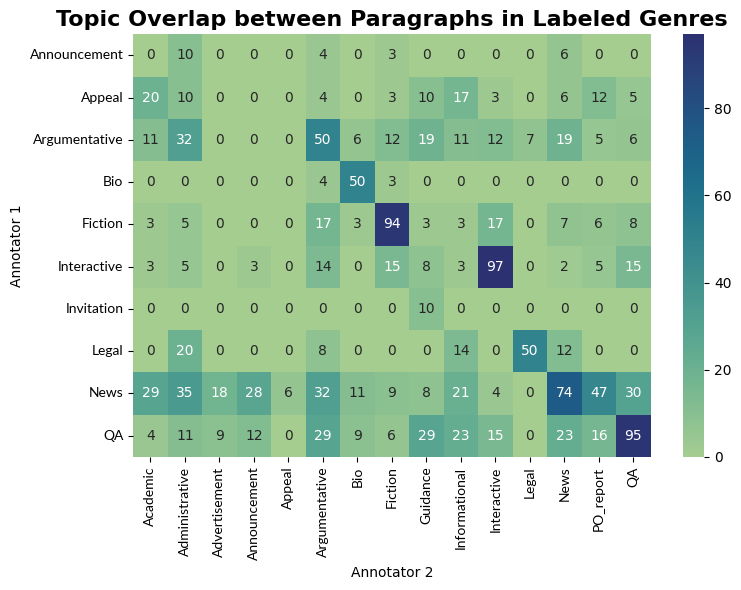

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(topic_overlap_cm, annot=True, fmt = "d", cmap=sns.color_palette("crest", as_cmap=True),
            )
plt.title("Topic Overlap between Paragraphs in Labeled Genres", fontsize=16, fontweight='bold')
plt.xlabel("Annotator 2")
plt.ylabel("Annotator 1")
plt.xticks(fontsize=10, fontfamily='Lato')
plt.yticks(fontsize=10, fontfamily='Lato')
plt.tight_layout()
plt.savefig(f'figures/TopicOverlap_{language}_{part_no}.png', dpi=330)  
plt.show()


## Correlation/Strength of Association Measurement

In [334]:
ann1_col = 'Annotator 1'
ann2_col = 'Annotator 2'

agreement_mask = (
    (df[ann1_col] == df[ann2_col]) &
    (df[ann1_col].notna()) &
    (df[ann2_col].notna())
)
plot_df = df.copy()
plot_df['Group'] = np.where(agreement_mask, 'Agreement', 'Disagreement')
plot_df['group_binary'] = (plot_df['Group'] == 'Disagreement').astype(int)

In [335]:
agreement_matrix = pd.crosstab(plot_df['Annotator 1'], plot_df['Annotator 2'])

# Flatten all values into 1D vectors
agreement_flat_all = agreement_matrix.values.flatten()
semantic_flat_all = semantic_similarity_cm.values.flatten()
structural_flat_all = structural_similarity_cm.values.flatten()
overlap_flat_all = topic_overlap_cm.values.flatten()

# Calculate Spearman's Rank Correlation
corr_sem_all = stats.spearmanr(agreement_flat_all, semantic_flat_all)
corr_str_all = stats.spearmanr(agreement_flat_all, structural_flat_all)
corr_over_all = stats.spearmanr(agreement_flat_all, overlap_flat_all)

print("\n--- Full Matrix Correlation ---")
print(f"Semantic Sim vs. Agreement:  rho={corr_sem_all.correlation:.4f}, p-value={corr_sem_all.pvalue:.4g}")
print(f"Structural Sim vs. Agreement: rho={corr_str_all.correlation:.4f}, p-value={corr_str_all.pvalue:.4g}")
print(f"Topic Overlap vs. Agreement: rho={corr_over_all.correlation:.4f}, p-value={corr_over_all.pvalue:.4g}")



--- Full Matrix Correlation ---
Semantic Sim vs. Agreement:  rho=0.3288, p-value=4.541e-07
Structural Sim vs. Agreement: rho=0.3440, p-value=1.201e-07
Topic Overlap vs. Agreement: rho=0.5652, p-value=2.145e-20


In [336]:
# set diagonals to NaN
agreement_offdiag = agreement_matrix.copy().astype(float)
np.fill_diagonal(agreement_offdiag.values, np.nan)

semantic_offdiag = semantic_similarity_cm.copy().astype(float)
np.fill_diagonal(semantic_offdiag.values, np.nan)

structural_offdiag = structural_similarity_cm.copy().astype(float)
np.fill_diagonal(structural_offdiag.values, np.nan)

overlap_offdiag = topic_overlap_cm.copy().astype(float)
np.fill_diagonal(overlap_offdiag.values, np.nan)

# Flatten and drop all NaN values to align the vectors
agreement_flat_off = agreement_offdiag.values.flatten()
agreement_flat_off = agreement_flat_off[~np.isnan(agreement_flat_off)]

semantic_flat_off = semantic_offdiag.values.flatten()
semantic_flat_off = semantic_flat_off[~np.isnan(semantic_flat_off)]

structural_flat_off = structural_offdiag.values.flatten()
structural_flat_off = structural_flat_off[~np.isnan(structural_flat_off)]

overlap_flat_off = overlap_offdiag.values.flatten()
overlap_flat_off = overlap_flat_off[~np.isnan(overlap_flat_off)]

# Calculate Spearman's Rank Correlation
corr_sem_off = stats.spearmanr(agreement_flat_off, semantic_flat_off)
corr_str_off = stats.spearmanr(agreement_flat_off, structural_flat_off)
corr_over_off = stats.spearmanr(agreement_flat_off, overlap_flat_off)

print("\n--- Off-Diagonal Correlation (Disagreement) ---")
print(f"Semantic Sim vs. Disagreement:  rho={corr_sem_off.correlation:.4f}, p-value={corr_sem_off.pvalue:.4g}")
print(f"Structural Sim vs. Disagreement: rho={corr_str_off.correlation:.4f}, p-value={corr_str_off.pvalue:.4g}")
print(f"Topic Overlap vs. Disagreement: rho={corr_over_off.correlation:.4f}, p-value={corr_over_off.pvalue:.4g}")


--- Off-Diagonal Correlation (Disagreement) ---
Semantic Sim vs. Disagreement:  rho=0.1887, p-value=0.006087
Structural Sim vs. Disagreement: rho=0.3279, p-value=1.18e-06
Topic Overlap vs. Disagreement: rho=0.4725, p-value=4.45e-13


In [304]:
plot_df.columns

Index(['fname', 'periodical', 'id', 'year', 'nr', 'page', 'paragraph',
       'Annotator 1', 'Annotator 2', 'embedding', 'unique_tokens',
       'avg_sent_len', 'avg_word_len', 'ttr', 'lexical_density',
       'readability_lix', 'avg_tree_height', 'avg_dep_dist', 'noun_ratio',
       'verb_ratio', 'adj_ratio', 'adv_ratio', 'adp_ratio', 'pron_ratio',
       'sconj_ratio', 'cconj_ratio', 'part_ratio', 'punct_ratio', 'num_ratio',
       'aux_ratio', 'propn_ratio', 'topic', 'Group', 'group_binary'],
      dtype='object')

In [239]:
plot_df = plot_df.loc[:, ~plot_df.columns.duplicated()]

In [337]:
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

ann1_col = 'Annotator 1'
ann2_col = 'Annotator 2'

agreement_mask = (
    (df[ann1_col] == df[ann2_col]) &
    (df[ann1_col].notna()) &
    (df[ann2_col].notna())
)
plot_df['Group'] = np.where(agreement_mask, 'Agreement', 'Disagreement')
plot_df['group_binary'] = (plot_df['Group'] == 'Disagreement').astype(int)

COLS_TO_EXCLUDE = [
    # Identifiers
    'fname', 'periodical', 'id', 'year', 'nr', 'page', 'paragraph',
    # Labels
    'Annotator 1', 'Annotator 2',
    # Raw data objects
    'embedding', 'unique_tokens',
    # Categorical feature
    'topic', 
    # Helper columns
    'nA', 'nB',
    # Target variables
    'Group', 'group_binary' 
]


In [ ]:

features_to_test = [col for col in plot_df.columns if col not in COLS_TO_EXCLUDE]

correlation_results = []
scaler = StandardScaler()

for feature in features_to_test:
    
    valid_idx = plot_df[feature].notna() & plot_df['group_binary'].notna()
    if valid_idx.sum() < 20: # Skip if not enough data
        print(f"Skipping {feature}: Not enough valid data.")
        continue
        
    y = plot_df.loc[valid_idx, 'group_binary']
    X_continuous = plot_df.loc[valid_idx, feature]

    r_rb, p_mwu = np.nan, np.nan
    r_pb, p_pb = np.nan, np.nan
    auc, p_logit = np.nan, np.nan

    try:
        feat_agree = plot_df.loc[valid_idx & (plot_df['group_binary'] == 0), feature]
        feat_disagree = plot_df.loc[valid_idx & (plot_df['group_binary'] == 1), feature]
        
        n_agree_feat = len(feat_agree)
        n_disagree_feat = len(feat_disagree)
        
        if n_agree_feat > 0 and n_disagree_feat > 0:
            # Note: mwu(disagree, agree) gives U for disagree group
            mwu_stat, p_mwu = stats.mannwhitneyu(feat_disagree, feat_agree, alternative='two-sided')
            # U statistic is for the *first* group (disagree)
            r_rb = (2 * mwu_stat) / (n_agree_feat * n_disagree_feat) - 1
        
        r_pb, p_pb = stats.pointbiserialr(X_continuous, y)

        X_scaled = scaler.fit_transform(X_continuous.values.reshape(-1, 1))
        X_with_const = sm.add_constant(X_scaled)
        
        model = sm.Logit(y, X_with_const)
        result = model.fit(disp=0)
        
        y_pred_proba = result.predict(X_with_const)
        auc = roc_auc_score(y, y_pred_proba)
        p_logit = result.pvalues[1] # p-value for the feature

    except Exception as e:
        print(f"Failed to calculate stats for {feature}: {e}")

    correlation_results.append({
        'Feature': feature,
        'Rank-Biserial_r': r_rb,
        'MWU_p_value': p_mwu,
        'Point-Biserial_r': r_pb,
        'PBR_p_value': p_pb,
        'AUC': auc,
        'Logit_p_value': p_logit
    })

results_df = pd.DataFrame(correlation_results)
results_df = results_df.set_index('Feature').dropna(how='all')
results_df = results_df.sort_values(by='AUC', ascending=False)

results_df

Failed to calculate stats for INilsson: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Failed to calculate stats for language: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Failed to calculate stats for part_no: Singular matrix


/zpool/aurora-main/scratch/vera/qwen3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/zpool/aurora-main/scratch/vera/qwen3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



,Rank-Biserial_r,MWU_p_value,Point-Biserial_r,PBR_p_value,AUC,Logit_p_value
Feature,,,,,,
topic_overlap,-1.000000,6.225785e-89,-0.883495,0.000000e+00,1.000000,9.521257e-01
structural_similarity,-0.910420,2.835621e-77,-0.611840,2.471799e-103,0.955210,9.027309e-30
level_0,-0.668792,1.944779e-39,-0.416568,4.401543e-43,0.834396,6.132135e-29
index,-0.668792,1.944779e-39,-0.503131,5.011369e-65,0.834396,1.539490e-39
punct_ratio,-0.604180,1.349112e-32,-0.329261,1.298592e-26,0.802090,1.136092e-17
avg_tree_height,0.585799,3.893111e-31,0.367575,3.193680e-33,0.792900,2.726964e-24
avg_sent_len,0.559951,3.270982e-28,0.307465,2.996130e-23,0.779976,5.693203e-17
readability_lix,0.553014,1.637502e-27,0.327417,2.563212e-26,0.776507,1.152082e-20
avg_dep_dist,0.506696,1.814859e-23,0.320844,2.787260e-25,0.753348,8.109986e-20


In [339]:
df_topics = plot_df[plot_df['topic'] != -1].copy()
# df_topics = plot_df
contingency_table = pd.crosstab(df_topics['Group'], df_topics['topic'])

if contingency_table.empty or contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
    print("\nCannot run statistical tests: Not enough data or categories.")
else:
    # chi 2
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    
    # Cramér's V 
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    print("\n--- Statistical Test Results ---")
    print(f"Chi-Squared Statistic: {chi2:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Cramér's V (Strength): {cramers_v:.4f}")

    if p_value <= 0.05:
        print(f"\nConclusion: There is a statistically significant relationship (p={p_value:.4f}).")
        print(f"The strength of this relationship is {cramers_v:.4f} (Cramér's V).")
    else:
        print(f"\nConclusion: There is no statistically significant relationship (p={p_value:.4f}).")


--- Statistical Test Results ---
Chi-Squared Statistic: 559.5520
P-value: 0.0000
Cramér's V (Strength): 0.7006

Conclusion: There is a statistically significant relationship (p=0.0000).
The strength of this relationship is 0.7006 (Cramér's V).


## Paired Boxplots

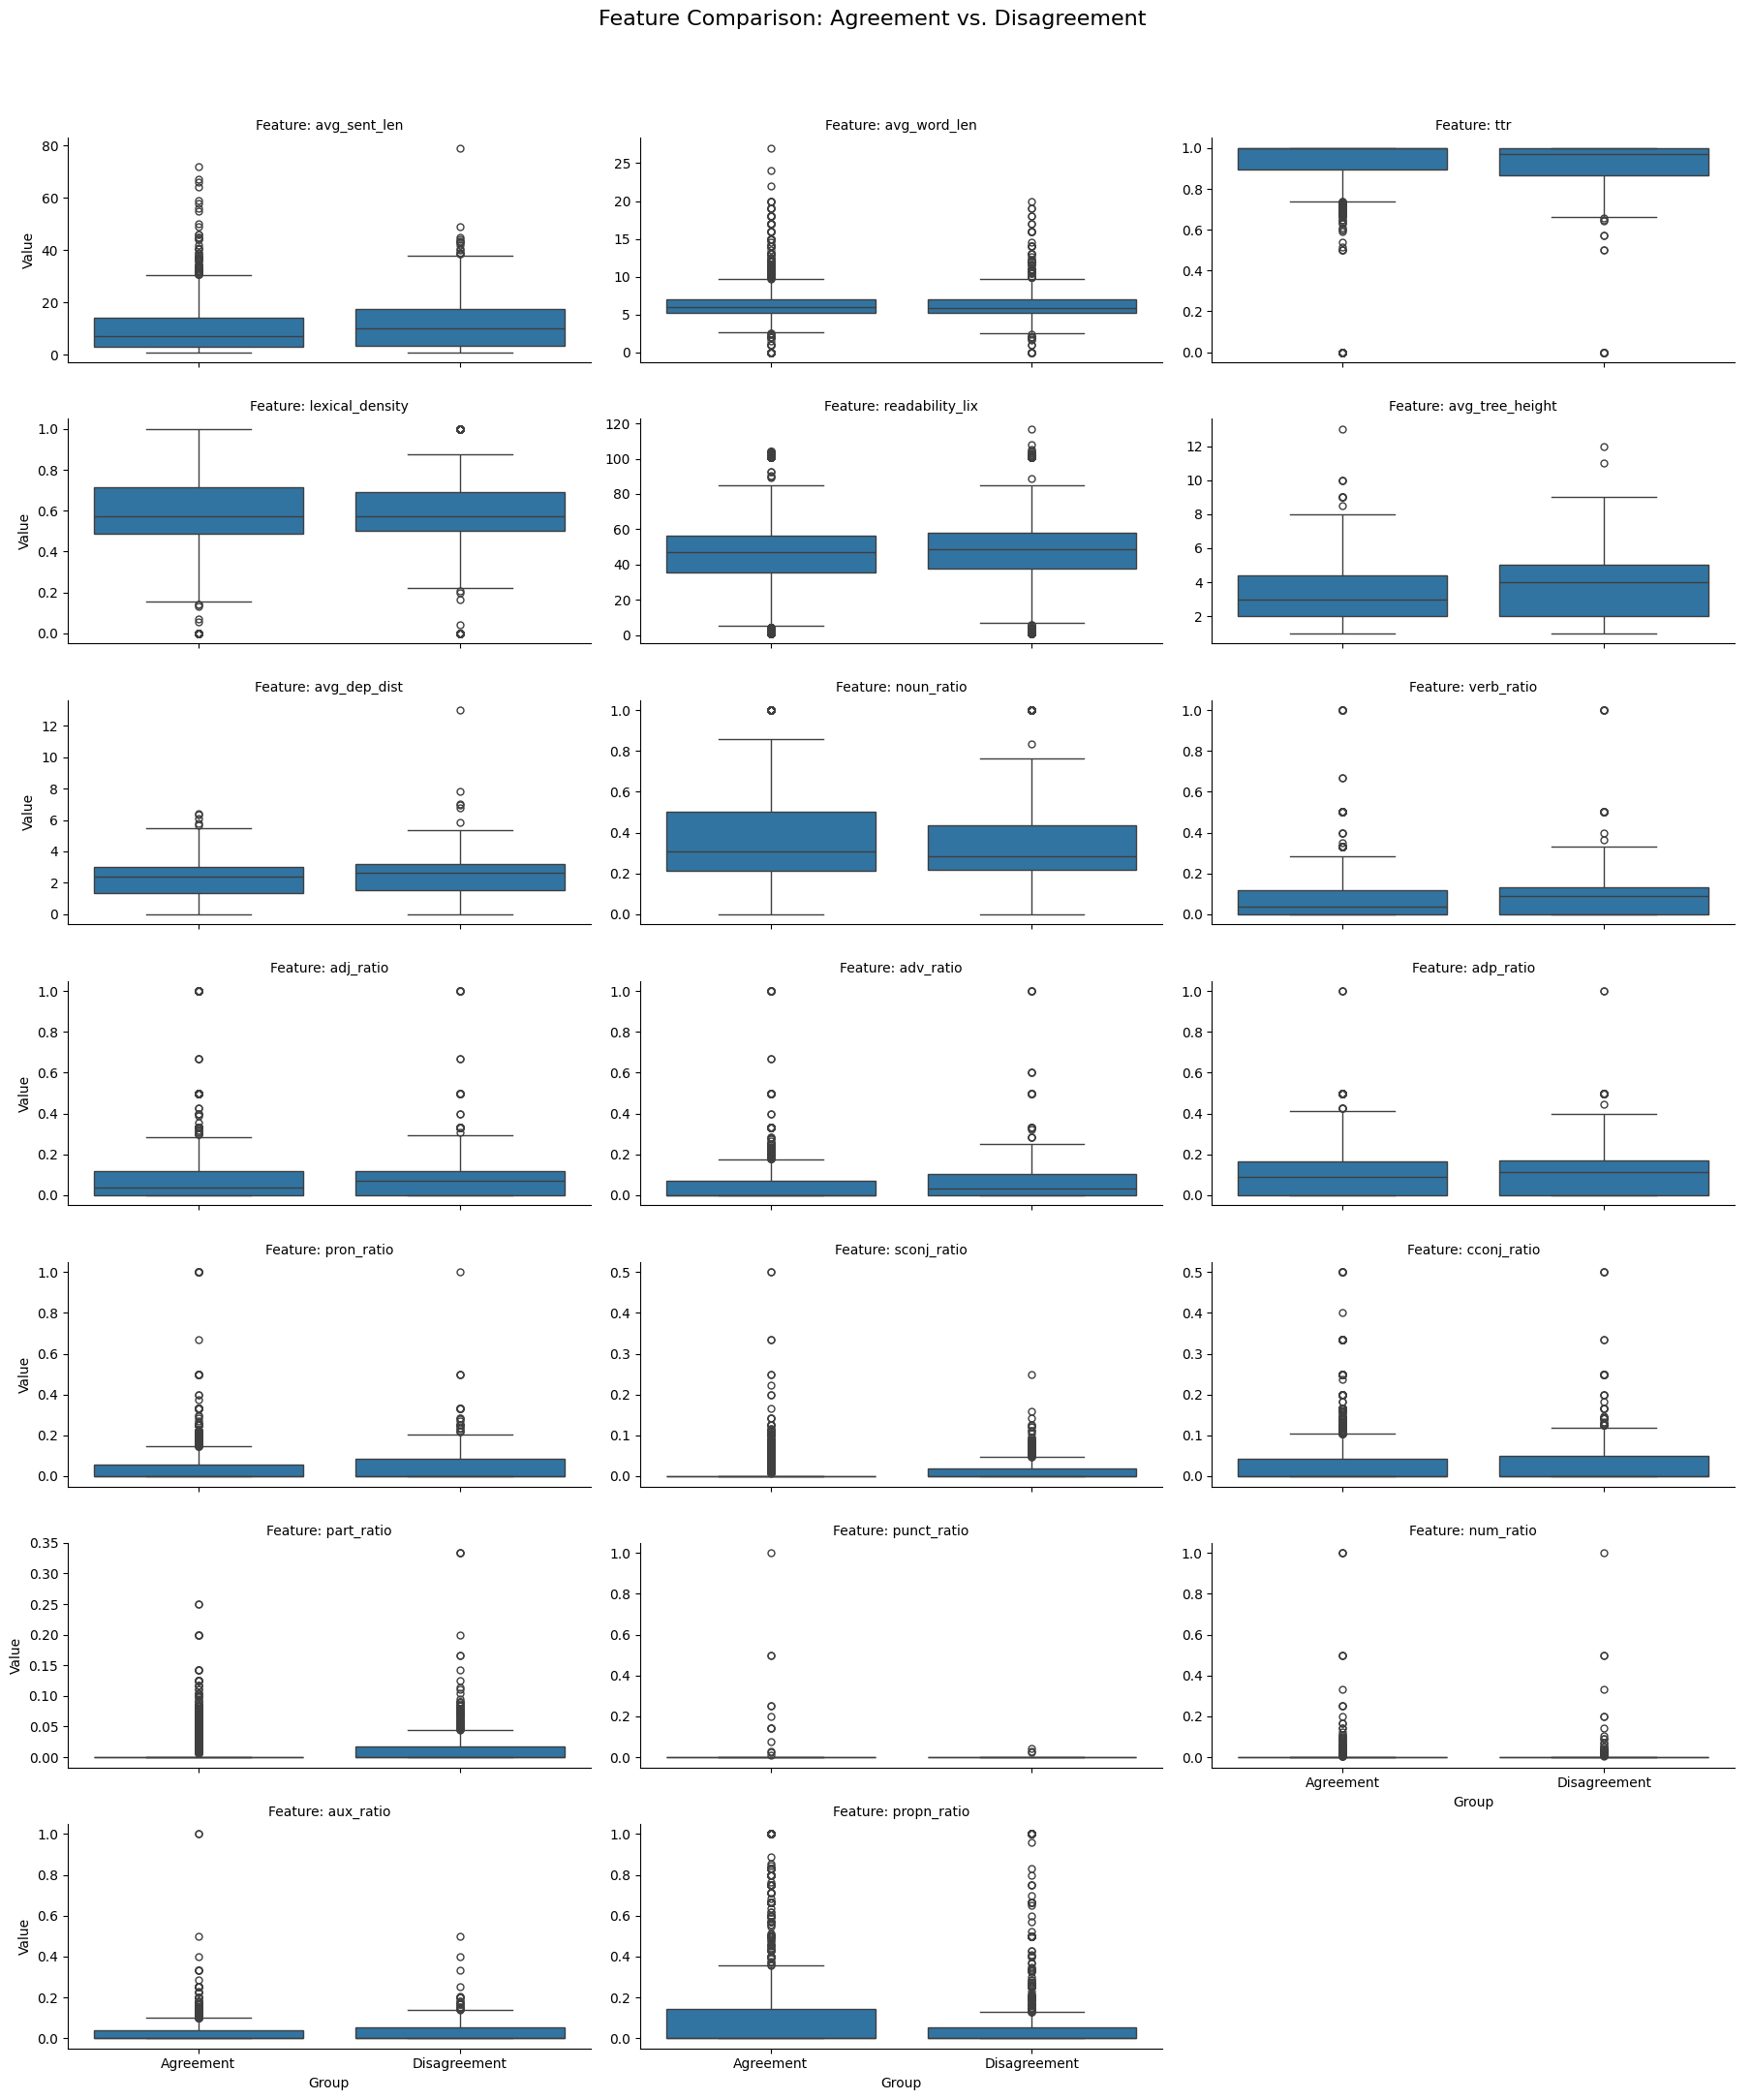

In [184]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plot_df = df[features_names].copy()
plot_df['Group'] = np.where(agreement_mask, 'Agreement', 'Disagreement')

df_long = plot_df.melt(
    id_vars=['Group'], 
    var_name='Feature',  
    value_name='Value' )

g = sns.catplot(
    data=df_long,
    x='Group',          # X-axis: Agreement vs Disagreement
    y='Value',          # Y-axis: The value of the feature
    col='Feature',      
    kind='box',         
    col_wrap=3,         # Wrap to the next line after 3 plots (adjust as needed)
    sharey=False,       
    height=3,           
    aspect=2,         # Aspect ratio (width/height)
    order=['Agreement', 'Disagreement'] # Ensures consistent order
)

g.fig.suptitle('Feature Comparison: Agreement vs. Disagreement', y=1.03, fontsize=16)
g.set_axis_labels("Group", "Value")
g.set_titles("Feature: {col_name}")

plt.tight_layout()
plt.show()

## Ratios

In [187]:
def get_specific_baseline_mean(disagreement_pair):

    label1, label2 = disagreement_pair
    
    baseline_pair_1 = (label1, label1)
    baseline_pair_2 = (label2, label2)
    
    valid_baseline_pairs = [
        p for p in [baseline_pair_1, baseline_pair_2] 
        if p in agreement_pair_stats.index
    ]
    
    if valid_baseline_pairs:
        return agreement_pair_stats.loc[valid_baseline_pairs].mean()
    else:
        return agreement_pair_stats_all

related_agreement_pair_stats = disagreement_pair_stats.index.to_series().apply(get_specific_baseline_mean)

In [188]:
disagree_agree_ratio = disagreement_pair_stats/related_agreement_pair_stats

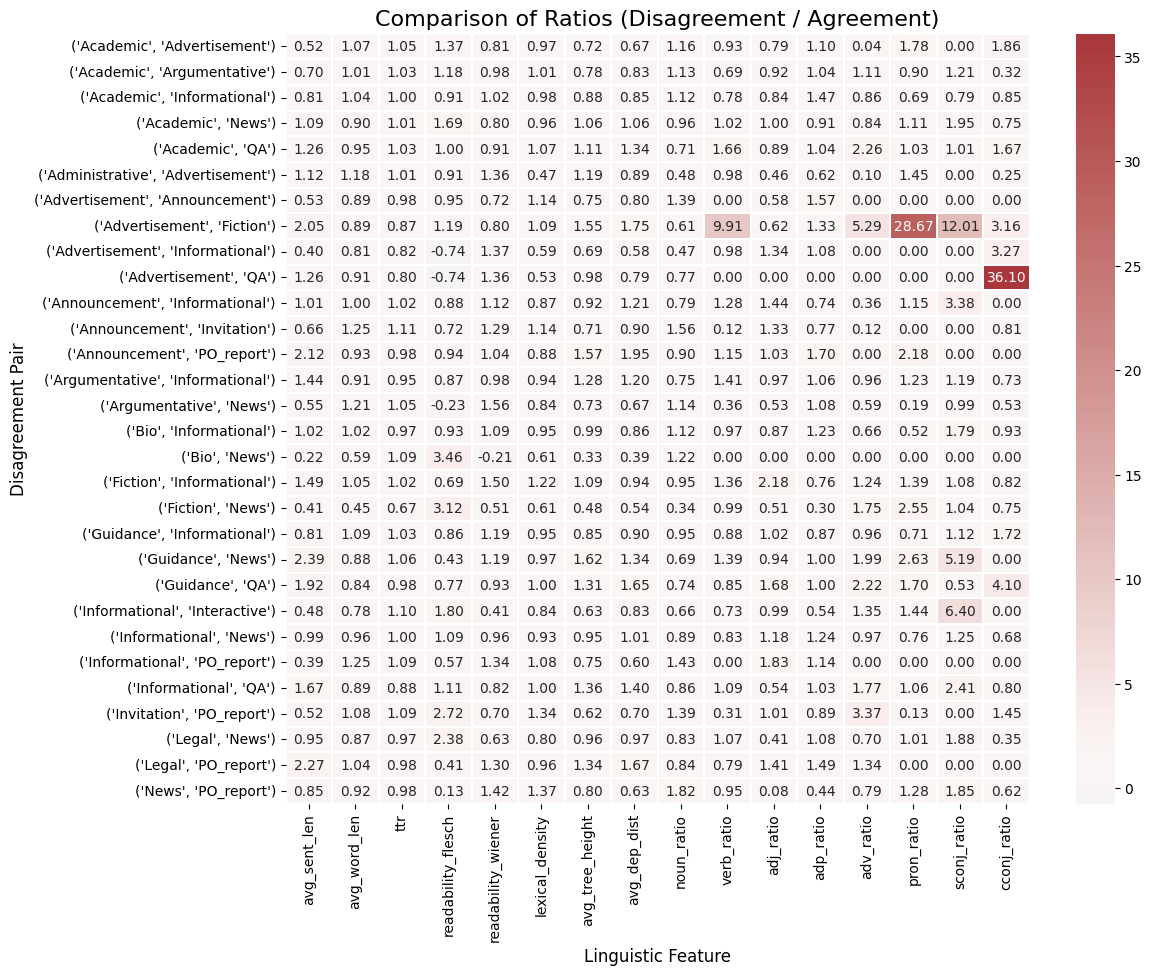

In [189]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    disagree_agree_ratio,
    annot=True,
    fmt=".2f",
    linewidths=.3,
    cmap="vlag",  
    center=1.0    
)
plt.title("Comparison of Ratios (Disagreement / Agreement)", fontsize=16)
plt.ylabel("Disagreement Pair", fontsize=12)
plt.xlabel("Linguistic Feature", fontsize=12)
plt.show()

# Extract Double-Annotated Data

In [ ]:
group_keys = ['part_no', 'language', 'fname', 'periodical', 'year', 'nr', 'page', 'paragraph']
grouped = merged_df.groupby(group_keys)['genre']\
.agg(list).apply(pd.Series)


In [40]:
double_voted=grouped.apply(lambda df: df.value_counts().idxmax() if any(df.value_counts() >= 2) else None, axis=1).dropna(axis=0).reset_index(name='genre')

In [54]:
once_voted=grouped.query('part_no == 1 and language == "swe"').apply(lambda df: df.value_counts().idxmax() if df.value_counts().max() == 1 else None, axis=1).dropna(axis=0).reset_index(name='genre')

In [61]:
dataset = pd.concat([once_voted, double_voted], axis=0).reset_index(drop=True)

In [62]:
dataset.genre.value_counts()

genre
PO_report         3409
Advertisement     2164
Informational     1595
Guidance          1591
Fiction           1108
Argumentative     1010
Academic           693
Bio                578
Administrative     431
Interactive        400
Invitation         279
Legal              273
Announcement       272
QA                 215
Appeal             150
News               134
Name: count, dtype: int64

In [ ]:
# dataset.to_parquet('genre_training_data_swe_part1_and_double_voted.parquet', index=False)